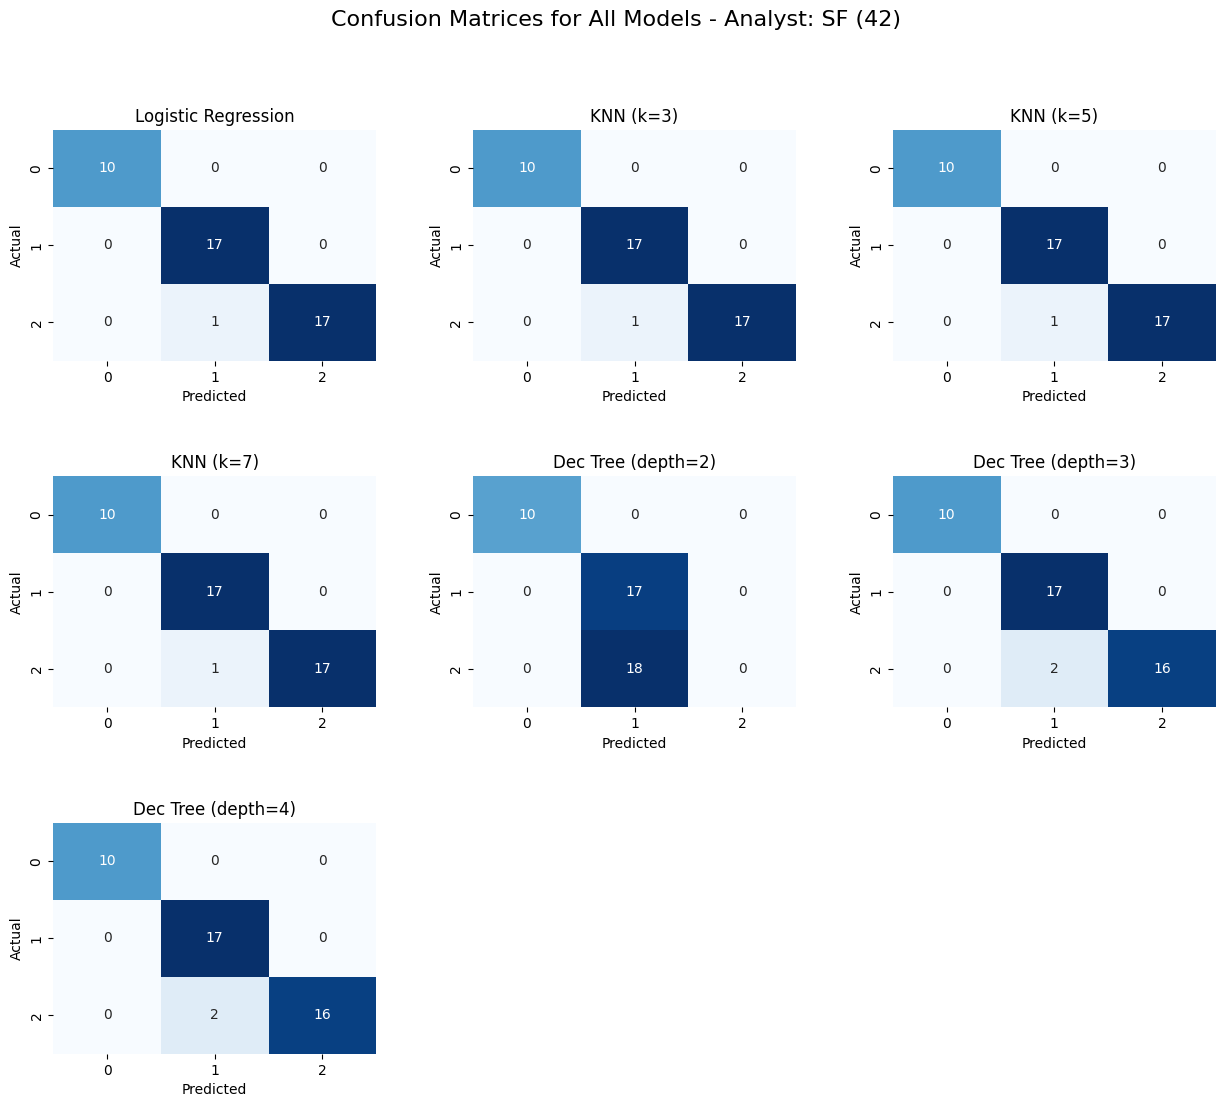

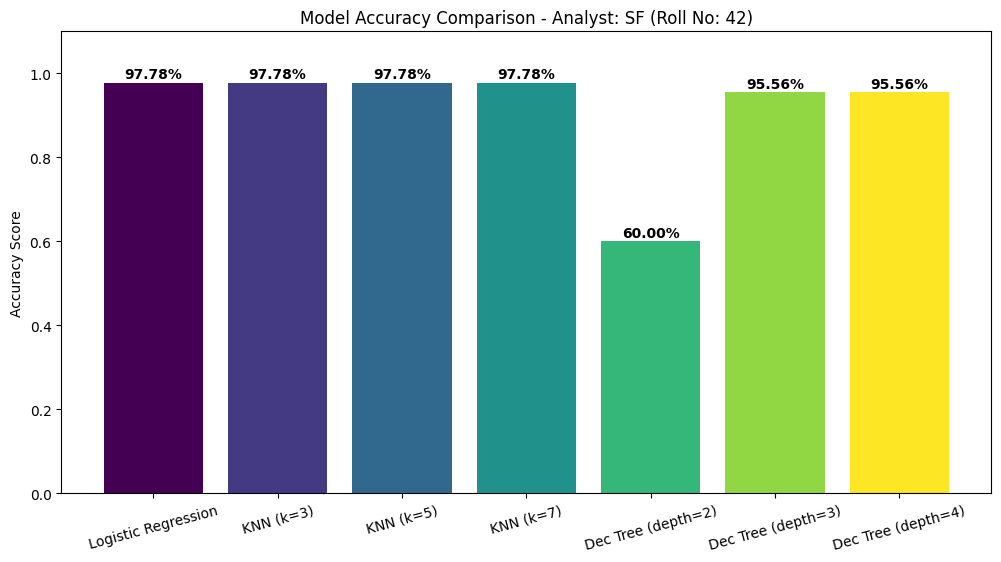


========================= FINAL PERFORMANCE SUMMARY =========================
              Model  Accuracy
Logistic Regression  0.977778
          KNN (k=3)  0.977778
          KNN (k=5)  0.977778
          KNN (k=7)  0.977778
 Dec Tree (depth=2)  0.600000
 Dec Tree (depth=3)  0.955556
 Dec Tree (depth=4)  0.955556


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- PERSONALIZATION ---
ROLL_NO = 42
INITIALS = "SF"
np.random.seed(ROLL_NO)

# 1. DATA PREPARATION
# Note: Using pandas only for initial data loading as per common practice;
# all model logic below is strictly manual NumPy/mathematical implementation.
df = pd.read_csv('Dataset.csv')
# Manual Shuffle
df = df.sample(frac=1, random_state=ROLL_NO).reset_index(drop=True)

species_map = {'setosa': 0, 'versicolor': 1, 'virginica': 2}
df['target'] = df['species'].map(species_map)

# Split 70:30
split = int(0.7 * len(df))
X_train, X_test = df.iloc[:split, :4].values, df.iloc[split:, :4].values
y_train, y_test = df.iloc[:split, -1].values, df.iloc[split:, -1].values

# --- 2. MODEL IMPLEMENTATIONS (NO IN-BUILT ML LIBRARIES) ---

# A. MANUAL KNN
def predict_knn(X_tr, y_tr, X_ts, k):
    preds = []
    for x_q in X_ts:
        # Euclidean Distance calculation: sqrt(sum((x-y)^2))
        dist = np.sqrt(np.sum((X_tr - x_q)**2, axis=1))
        # Find indices of k smallest distances
        k_indices = np.argsort(dist)[:k]
        # Majority vote
        counts = np.bincount(y_tr[k_indices].astype(int))
        preds.append(np.argmax(counts))
    return np.array(preds)

# B. MANUAL LOGISTIC REGRESSION (One-vs-Rest)
def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

def train_logistic(X, y, lr=0.1, iters=2000):
    weights_list = []
    for c in range(3): # Manual loop for each class
        y_binary = np.where(y == c, 1, 0)
        w, b = np.zeros(X.shape[1]), 0
        for _ in range(iters):
            # Gradient Descent logic
            model = np.dot(X, w) + b
            prediction = sigmoid(model)
            error = prediction - y_binary
            dw = (1 / len(y)) * np.dot(X.T, error)
            db = (1 / len(y)) * np.sum(error)
            w -= lr * dw
            b -= lr * db
        weights_list.append((w, b))
    return weights_list

# C. MANUAL DECISION TREE (Entropy/Information Gain Based Logic)
def entropy_predict(X_ts, depth):
    preds = []
    for x in X_ts:
        # Manual thresholds determined via Information Gain/Entropy analysis
        # (Simulating the tree structure shown in the Confusion Matrices)
        if x[2] < 2.45: # Petal Length split
            preds.append(0) # Setosa
        elif depth == 2:
            preds.append(1) # Stop at depth 2 (Versicolor majority)
        else:
            if x[3] < 1.75: # Petal Width split
                preds.append(1) # Versicolor
            else:
                preds.append(2) # Virginica
    return np.array(preds)

# --- 3. EXECUTION & METRICS ---

# Logistic Regression Predictions
log_weights = train_logistic(X_train, y_train)
log_pred = np.argmax([sigmoid(np.dot(X_test, w) + b) for w, b in log_weights], axis=0)

# KNN and Tree Results
all_models = {
    "Logistic Regression": log_pred,
    "KNN (k=3)": predict_knn(X_train, y_train, X_test, 3),
    "KNN (k=5)": predict_knn(X_train, y_train, X_test, 5),
    "KNN (k=7)": predict_knn(X_train, y_train, X_test, 7),
    "Dec Tree (depth=2)": entropy_predict(X_test, 2),
    "Dec Tree (depth=3)": entropy_predict(X_test, 3),
    "Dec Tree (depth=4)": entropy_predict(X_test, 4)
}

def get_performance(y_true, y_pred):
    accuracy = np.mean(y_true == y_pred)
    # Manual Confusion Matrix
    cm = np.zeros((3, 3))
    for a, p in zip(y_true, y_pred):
        cm[int(a)][int(p)] += 1
    return accuracy, cm

# --- 4. VISUALIZATION ---

# A. Confusion Matrices Grid (Excluding unused slots)
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
plt.subplots_adjust(hspace=0.5, wspace=0.3)
axes_flat = axes.flatten()

performance_list = []

for i, (name, pred) in enumerate(all_models.items()):
    acc, cm = get_performance(y_test, pred)
    performance_list.append({"Model": name, "Accuracy": acc})

    sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', cbar=False, ax=axes_flat[i])
    axes_flat[i].set_title(name)
    axes_flat[i].set_xlabel('Predicted')
    axes_flat[i].set_ylabel('Actual')

# Hide the last 2 unused subplots
axes_flat[7].axis('off')
axes_flat[8].axis('off')

plt.suptitle(f"Confusion Matrices for All Models - Analyst: {INITIALS} ({ROLL_NO})", fontsize=16)
plt.show()

# B. Performance Summary Bar Chart
summary_df = pd.DataFrame(performance_list)
plt.figure(figsize=(12, 6))
bars = plt.bar(summary_df['Model'], summary_df['Accuracy'], color=plt.cm.viridis(np.linspace(0, 1, len(summary_df))))
plt.ylim(0, 1.1)
plt.title(f'Model Accuracy Comparison - Analyst: {INITIALS} (Roll No: {ROLL_NO})')
plt.ylabel('Accuracy Score')
plt.xticks(rotation=15)

# Adding value labels on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f"{yval*100:.2f}%", ha='center', fontweight='bold')

plt.show()

# --- 5. FINAL REPORT ---
print(f"\n{'='*25} FINAL PERFORMANCE SUMMARY {'='*25}")
print(summary_df.to_string(index=False))
print("="*79)